In [1]:
import numpy as np
from matplotlib import pyplot as plt
from astroML.datasets import generate_mu_z
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from scipy.stats import norm

(35.0, 50.0)

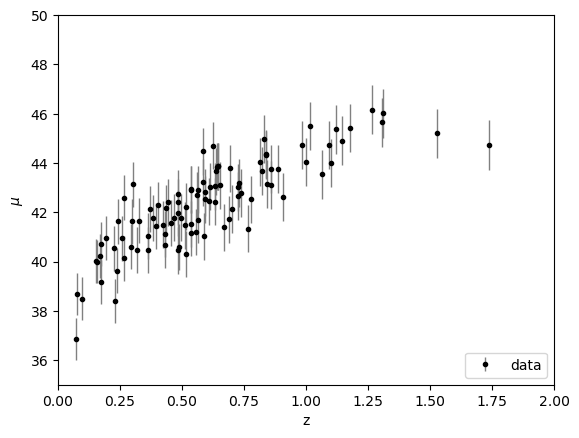

In [2]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) #generating the sample

#preliminary data plot
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

## GPR

We fit the data with Gaussian Process Regression, first k-fold cross validating for the hyperparameters. We then plot the expectation value of the fit, along with $1-\sigma$, $2-\sigma$ contours and the data 

{'alpha': np.float64(0.30000000000000004), 'kernel': 1**2 * RBF(length_scale=0.1)}


(35.0, 50.0)

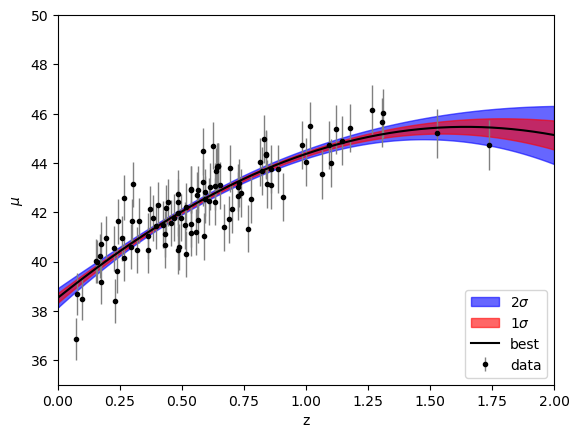

In [5]:
k = 10 # number of folds

#parameter grid for cross validation
param_grid = {
    'kernel': [
        ConstantKernel(1.0, (1e-3, 1e4))*RBF(0.1, (1e-4, 1e2))
    ],
    'alpha': np.linspace(0.1, 1., 10)
}


#cross validating
CV = GridSearchCV(GaussianProcessRegressor(), param_grid=param_grid, cv=k)
CV.fit(z_sample[:, np.newaxis], mu_sample)
best_params = CV.best_params_ # best hyperparameters
print(best_params)

#GPR
gpr = GaussianProcessRegressor(kernel=best_params['kernel'], alpha=best_params['alpha']) # GPR kernel
gpr.fit(z_sample[:, np.newaxis], mu_sample)

z_grid = np.linspace(0., 2., 10000)
mu_pred, mu_err = gpr.predict(z_grid[:, np.newaxis], return_std=True)

#plotting the results
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.fill_between(z_grid, mu_pred - 2*mu_err, mu_pred + 2*mu_err, color='blue', alpha=0.6, label='$2\sigma$')
plt.fill_between(z_grid, mu_pred - mu_err, mu_pred + mu_err, color='red', alpha=0.6, label='$1\sigma$')
plt.plot(z_grid, mu_pred, c='k', label='best')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

As expected, the uncertainty of the fit increases in areas with fewer data point (less constraints on the functions). 

In the $z > 1,75$ range the fit deviates significatly because of the absence of data

## Cloning the dataset

We now want to generate additional data by 'cloning' the original. To do it we sample in $z$ according to the density of the data (determined via a KDE). We then use the GPR results to extract  the associated $\mu$ values.

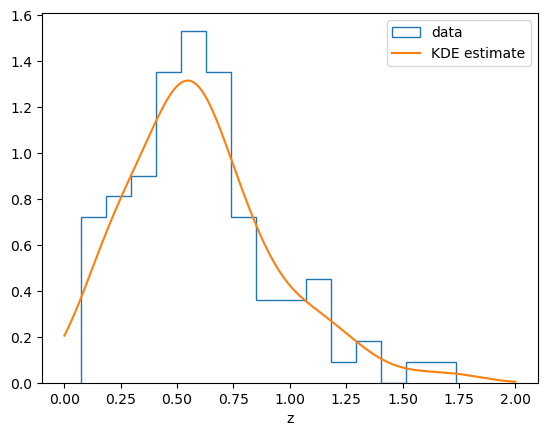

In [7]:
#cross validating the bandwidth of the kernels
bw_vals = np.linspace(0.05, 0.2, 100)
density_CV = GridSearchCV(KernelDensity(), {'bandwidth': bw_vals}, cv=10)
density_CV.fit(z_sample[:, np.newaxis])
bw_best = density_CV.best_params_['bandwidth']

#KDE
z_density = KernelDensity(bandwidth=bw_best)
z_density.fit(z_sample[:, np.newaxis])

#plotting the estimated pdf over a histo of the data
plt.hist(z_sample, 15, density=True, label='data', histtype='step')
plt.plot(z_grid, np.exp(z_density.score_samples(z_grid[:, np.newaxis])), label='KDE estimate')
plt.xlabel('z')
plt.legend()

(35.0, 50.0)

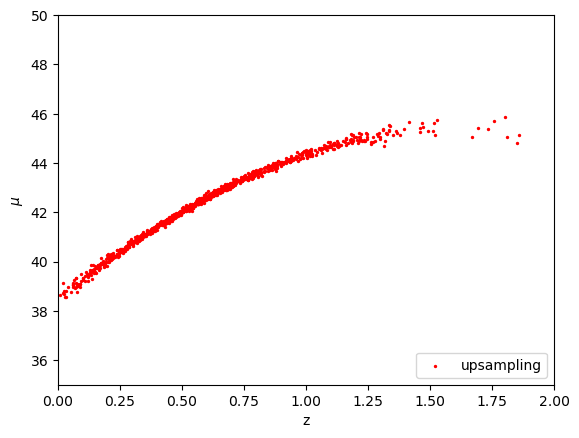

In [ ]:
z_new = z_density.sample(1000) # upsampling the z pdf
mu_new_mean, mu_new_err = gpr.predict(z_new, return_std=True) # predicting according to the gpr fit 

# extracting the new mu vals from gaussians with mean and std given by the gpr fit
mu_new = []
for i in range(len(z_new)):
    val = norm(mu_new_mean[i], mu_new_err[i]).rvs()
    mu_new.append(val)

mu_new = np.array(mu_new)

#plotting the upsampled data
plt.scatter(z_new, mu_new, c='r', s=2, label='upsampling')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)